## Автоматическое дифференцирование

Ранее мы с вами с нуля реализовали алгоритм back propagation для очень простой НС. И увидели, что в его основе лежит вычисление производной от выбранной функции потерь по вектору параметров $\vec{\omega}$:

$$
\frac{\partial L\left( f\left( \overline{x}_i; \overline{\omega} \right), y_i \right)}{\partial \overline{\omega}},
$$

которая зависит от функции $f\left( \overline{x}_i; \overline{\omega} \right)$, описывающей работу НС в целом. И при реализации алгоритма обучения мы самостоятельно вычисляли все необходимые производные для корректировки весов связей. Но, так как это важная, ключевая и, в общем-то, распространенная операция, то фреймоврк PyTorch предоставляет инструменты автоматизации вычисления производных.

### 1. Вычислительный граф

PyTorch выполняет численное дифференцирование методом обратного распространения (reverse-mode autodiff). Аналитический вид производных не ищется — вычисляются численные значения.

Например, функция:

$$
f(x, y) = (x + y)^2 + 2xy
$$

И мы хотим посчитать ее значения при разных x, y. Один из способов сделать это – построить граф вычислений. Общая идея вычислительного графа – представить целевую функцию набором элементарных математических операций (сложение, вычитание, умножение, деление) и стандартного набора функций (sin, cos, exp, log, sqrt и т.д.). Существует теорема, доказывающая, что любую непрерывную функцию можно представить с заданной точностью набором таких математических действий:

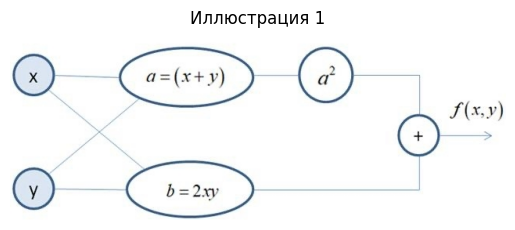

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/AutoDiff_1.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Эффективность здесь достигается за счет устранения дублирования при вычислениях (если они возникают), а также за счет распараллеливания независимых операций. Кроме того, как мы сейчас увидим, такой граф также позволяет эффективно вычислять и производные функции, что весьма полезно при разработке алгоритмов машинного обучения и, вообще, при решении различных оптимизационных задач.

Итак, вычислительный граф:

$$
a = (x + y)
$$
$$
b = 2xy
$$
$$
f = a^2 + b
$$

Цепное правило:

$$
\frac{\partial f}{\partial x} = \frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial x} + \frac{\partial f}{\partial b} \cdot \frac{\partial b}{\partial x}
$$
$$
\frac{\partial f}{\partial y} = \frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial y} + \frac{\partial f}{\partial b} \cdot \frac{\partial b}{\partial y}
$$

Аналитический вид производных:

$$
\frac{\partial f}{\partial x} = 2(x + y) + 2y
$$
$$
\frac{\partial f}{\partial y} = 2(x + y) + 2x
$$

Значения производных в точке \(x = 2, y = -4\): $\frac{\partial f}{\partial x} = -12$, $\frac{\partial f}{\partial y} = 0$.

Теперь вернемся к Pytorch. Процесс вычисления производных начинается с конца (истока), то есть, вычисляется производная $\frac{\partial f}{\partial f}=1$. Далее, в соответствии с цепным правилом, нам нужно вычислить производную по $a$:

$$
\frac{\partial f}{\partial a} = \frac{\partial (a^2 + b)}{\partial a} = \frac{\partial a^2}{\partial a} = 2a.
$$

Так как функциональные узлы вычислительного графа составлены из элементарных функций, то PyTorch «знает» аналитический вид их производных. И, в частности, «понимает», что $\frac{\partial f}{\partial a}=2a$. Само значение $a=-2y$. У нас было вычислено при прямом проходе по графу с $x = 2$, $y = -4$. Значит:

$$
\frac{\partial f}{\partial a} = 2a = 2 \cdot (-2) = -4.
$$

Далее, по цепному правилу нам нужно вычислить частную производную:

$$
\frac{\partial a}{\partial x} = \frac{\partial (x + y)}{\partial x} = \frac{\partial x}{\partial x} = 1.
$$

Она просто равна 1, поэтому $\frac{\partial a}{\partial x} \frac{\partial (x + y)}{\partial x} = -4 \cdot 1 = -4$. 

Аналогично сразу вычисляем и производную $\frac{\partial f}{\partial a} \frac{\partial a}{\partial y} = -4 \cdot 1 = -4$.

Следующим шагом нам нужно вычислить производную:

$$
\frac{\partial f}{\partial b} = \frac{\partial (a^2 + b)}{\partial b} = \frac{\partial b}{\partial b} = 1.
$$

И, затем, на основе частных производных $ \frac{\partial b}{\partial x} = 2y; \quad \frac{\partial b}{\partial y} = 2x$ вычислить их при $x = 2$, $y = -4$:

$$
\frac{\partial b}{\partial x} = 2 \cdot (-4) = -8; \quad \frac{\partial b}{\partial y} = 2 \cdot 2 = 4.
$$

Складываем полученные величины и находим частные производные функции по $x$ и $y$:

$$
\frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial x} = -4 \cdot 1 = -4
$$,

$$
\frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial y} = -4 \cdot 1 = -4
$$.

Вот так, с помощью вычислительного графа, мы определили значения производных функции $f(x,y)$ в точках $x = 2$, $y = -4$. Аналогичным образом находит значения производных и PyTorch.

### 3. Реализация вычислительного графа и автоматического дифферецирования

Чтобы увидеть, как вся эта математика реализуется на PyTorch, выполним вычисления производных этой же функции в той же точке $x = 2$, $y = -4$:

In [3]:
import torch
 
x = torch.tensor([2.0], requires_grad=True)
y = torch.tensor([-4.0], requires_grad=True)
 
f = (x + y) ** 2 + 2 * x * y
 
f.backward()
 
print(f)
 
print(x.data, x.grad)
print(y.data, y.grad)

tensor([-12.], grad_fn=<AddBackward0>)
tensor([2.]) tensor([-12.])
tensor([-4.]) tensor([0.])


Вначале объявляются два тензора $x$ и $y$ с вещественными значениями 2 и -4. Причем, у тензоров дополнительно указан аргумент requires_grad=True, который «указывает» фреймворку PyTorch вычислять для них градиенты. По умолчанию этот параметр равен False.

После этого вычисляется значение функции $f(x,y)$ по требуемой формуле. А, затем, происходит автоматическое дифференцирование путем вызова метода backward. В результате тензоры x и y будут содержать свойства:

1. x.data, y.data – исходное значение тензоров (то есть 2.0 и -4.0);
2. x.grad – значение производной $\frac{\partial f(x, y)}{\partial x}$ в точке $x = 2, y = -4$;
3. y.grad – значение производной $\frac{\partial f(x, y)}{\partial y}$ в точке $x = 2, y = -4$

Причем, программа будет корректно работать, даже если формулу расписать в несколько строчек с промежуточными переменными, например:

In [5]:
a = (x + y) ** 2
b = 2 * x * y
f = a + b
f.backward()

print(f)

tensor([-12.], grad_fn=<AddBackward0>)


Тензоры $x$ и $y$ в PyTorch – это не просто наборы чисел и операций с ними, а программные единицы, которые неявно взаимодействуют между собой. В частности, команды:

In [ ]:
a = (x + y) ** 2
b = 2 * x * y
f = a + b

Не только вычисляют итоговое значение $f$, но и формируют (неявно) граф вычислений, начиная с начальных значений тензоров $x$, $y$. Поэтому метод backward всегда имеет возможность вычислить численные значения производных для функции $f$.